# Random Forest Classifier
Dataset: [UCI Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality)

This file focuses on the **Random Forest Classifier** (`RandomForestClassifier`) library from _Scikit-learn_

In [1]:
## 0.0. Installing UCI ML Repo to pull dataset
!pip install ucimlrepo

## 0.1. Installing packages locally on machine
%conda install -y -c conda-forge python-graphviz    # graphviz
!pip install scikit-plot                            # scikit-plot library


Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [17]:
## Installing libraries
from ucimlrepo import fetch_ucirepo # importing database

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scikitplot as skplt
import graphviz

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

## 1. Project and Dataset Selection
From the UC Irvine ML Repo, we've selected the Wine Quality dataset. This is a **classification** task:
we predict wine quality from 11 lab-measured attributes (e.g. alcohol, acidity, sulphates).

In [4]:
# Fetching database
wine_quality = fetch_ucirepo(id=186) # id=186: wine quality database

## 2. Tree Model Building

In this section, we'll be performing data pre-processing, loading, model creation, parameter tuning using GridSearchCV, and results analysis. This section focuses on the Random Forest Classifier (`RandomForestClassifier`).

### 2.1. Pre-Processing
In this step, we are pre-processing the data loaded from the public URL of the [Wine Quality UCI ML Repo](https://archive.ics.uci.edu/dataset/186/wine+quality).

In [ ]:
#### 2.1.1. Loading data into Panda DataFrame
x = wine_quality.data.features
y = wine_quality.data.targets

wine_df = x.copy()
wine_df['quality'] = y

print('Features: {}, Target: {}, Combined: {}'.format(x.shape, y.shape, wine_df.shape))
wine_df.head()

Features: (6497, 11), Target: (6497, 1), Combined: (6497, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
#### 2.1.2. Examining data for consistency (i.e. checking NULLs, missing data, etc.)
wine_df.isna().sum # Checking for any NULL values

## 2.1.2.a. Handling missing values
fill_values = wine_df.mean(numeric_only=True)
wine_df = wine_df.fillna(fill_values)

wine_df.isna().sum()

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

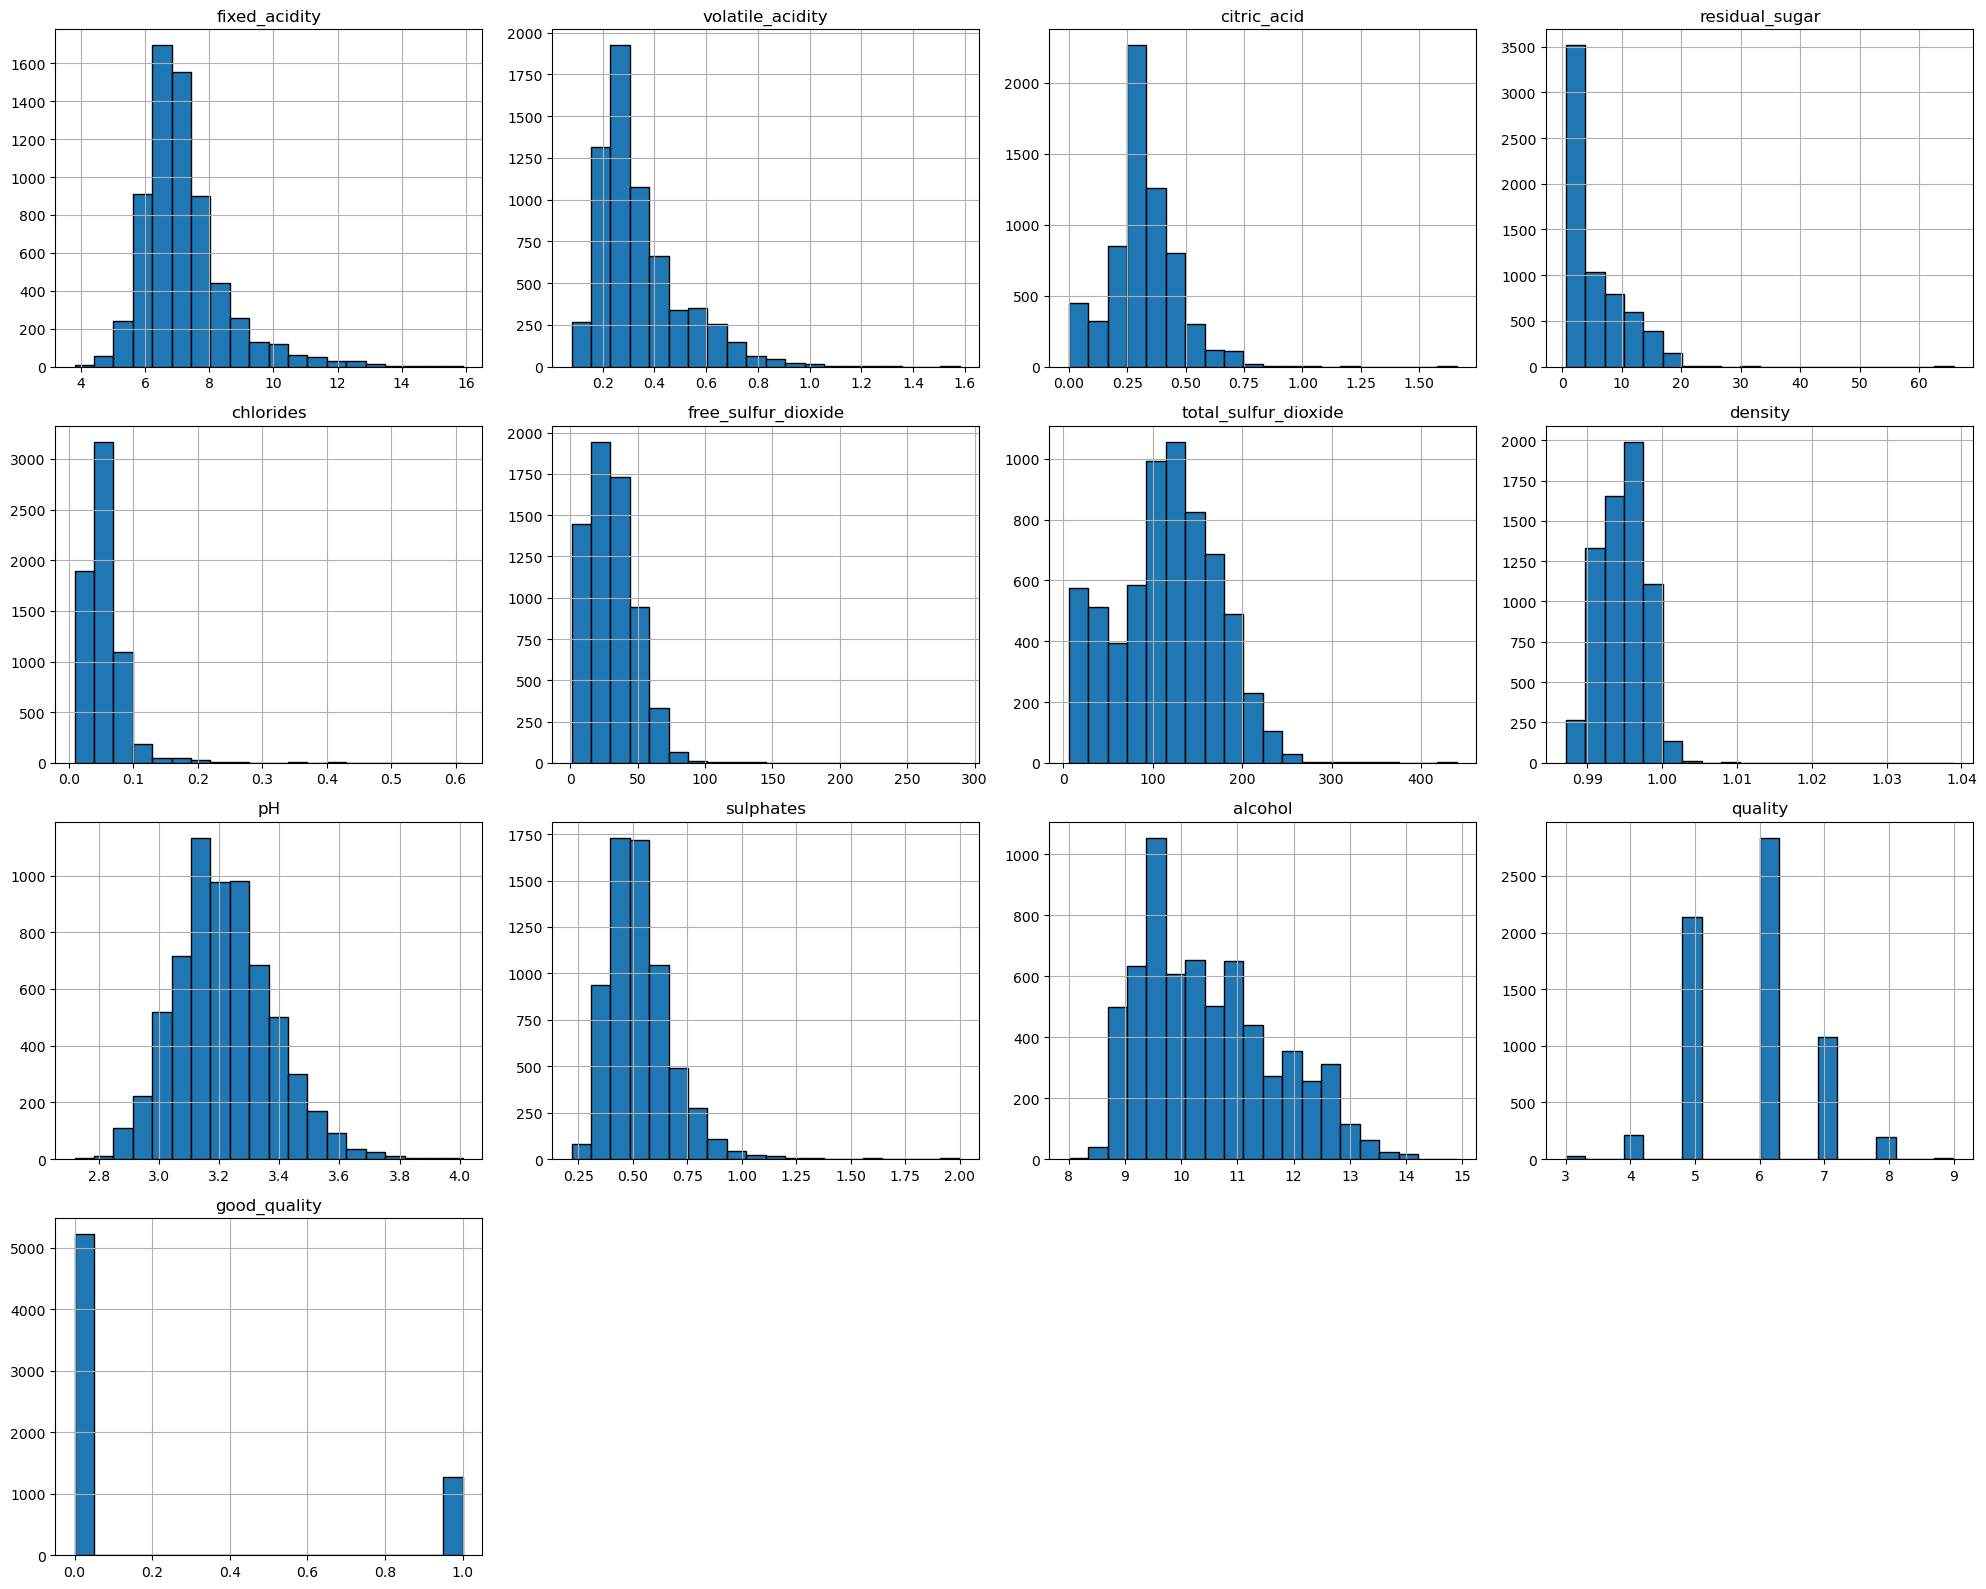

In [28]:
### 2.1.3. Examining attributes and target variables

## 2.1.3.a. Understanding the attributes (data types)
wine_df.dtypes

## 2.1.3.b. Converting target to binary class: good wine (quality >= 7) = 1, not good = 0
def LabelQuality(quality):
    if quality >= 7:
        return 1 # good
    else:
        return 0 # not good
    
wine_df['good_quality'] = wine_df['quality'].apply(LabelQuality) # applying binary function

## 2.1.3.c. Obtain and output summary of attributes
wine_df.describe()

## 2.1.3.d. Addressing if attributes are distributed normally
wine_df.select_dtypes(include='number').hist(bins=20, edgecolor='black', figsize=(20, 16))
plt.tight_layout()
plt.show()

In [8]:
### 2.1.4. Standardize and normalize the attributes
y = wine_df['good_quality']
x = wine_df.drop(['quality', 'good_quality'], axis = 1)

## 2.1.4.a. Standardized: Mean 0, Variance 1
x_std = pd.DataFrame(StandardScaler().fit_transform(x), columns = x.columns)
x_std.describe()

## 2.1.4.b. Noramlize: Rescale to a 0 to 1 range
x_norm = pd.DataFrame(MinMaxScaler().fit_transform(x), columns = x.columns)
x_norm.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,0.282257,0.173111,0.191948,0.074283,0.078129,0.102518,0.252868,0.146262,0.386435,0.174870,0.361131
std,0.107143,0.109758,0.087541,0.072972,0.058195,0.061630,0.130235,0.057811,0.124641,0.083599,0.172857
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.214876,0.100000,0.150602,0.018405,0.048173,0.055556,0.163594,0.100829,0.302326,0.117978,0.217391
50%,0.264463,0.140000,0.186747,0.036810,0.063123,0.097222,0.258065,0.149990,0.379845,0.162921,0.333333
75%,0.322314,0.213333,0.234940,0.115031,0.093023,0.138889,0.345622,0.190476,0.465116,0.213483,0.478261
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


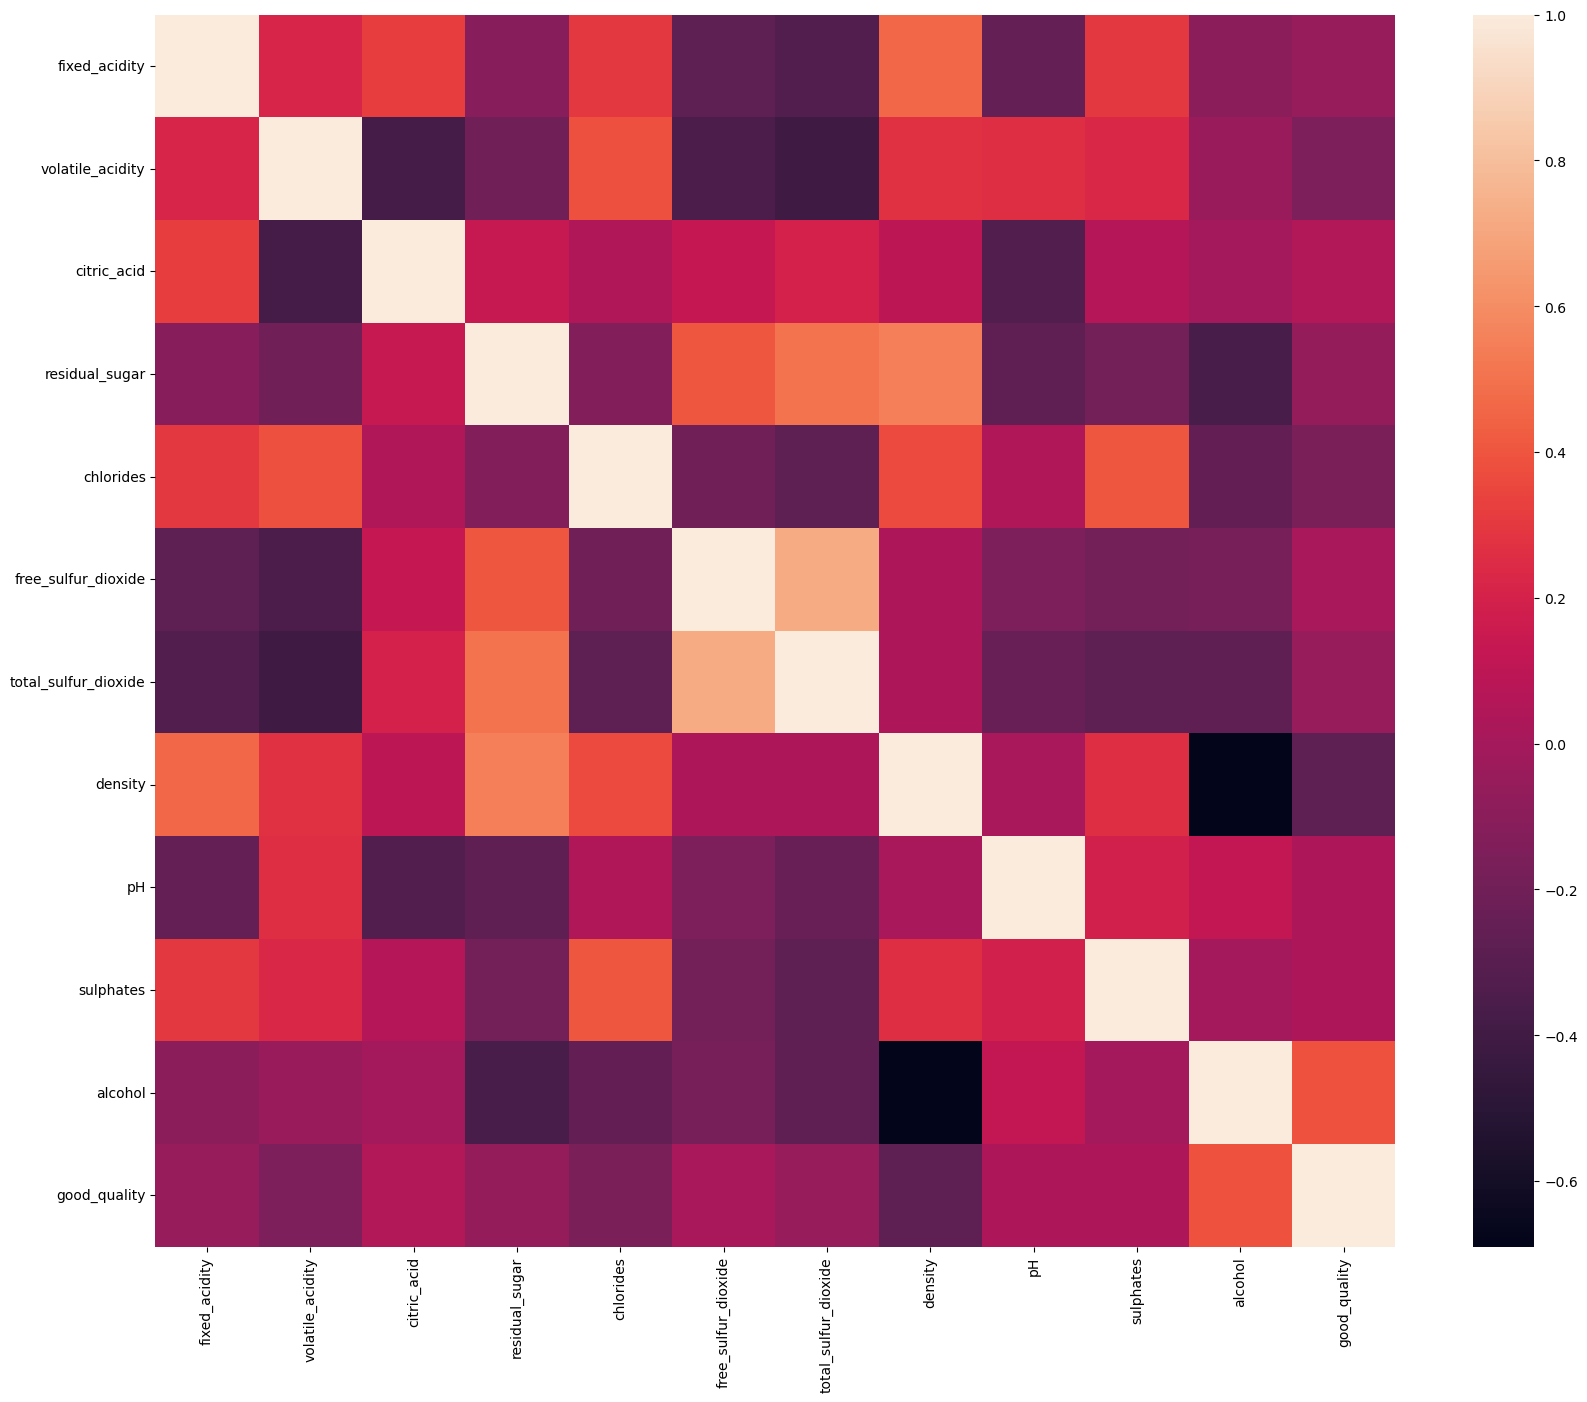

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

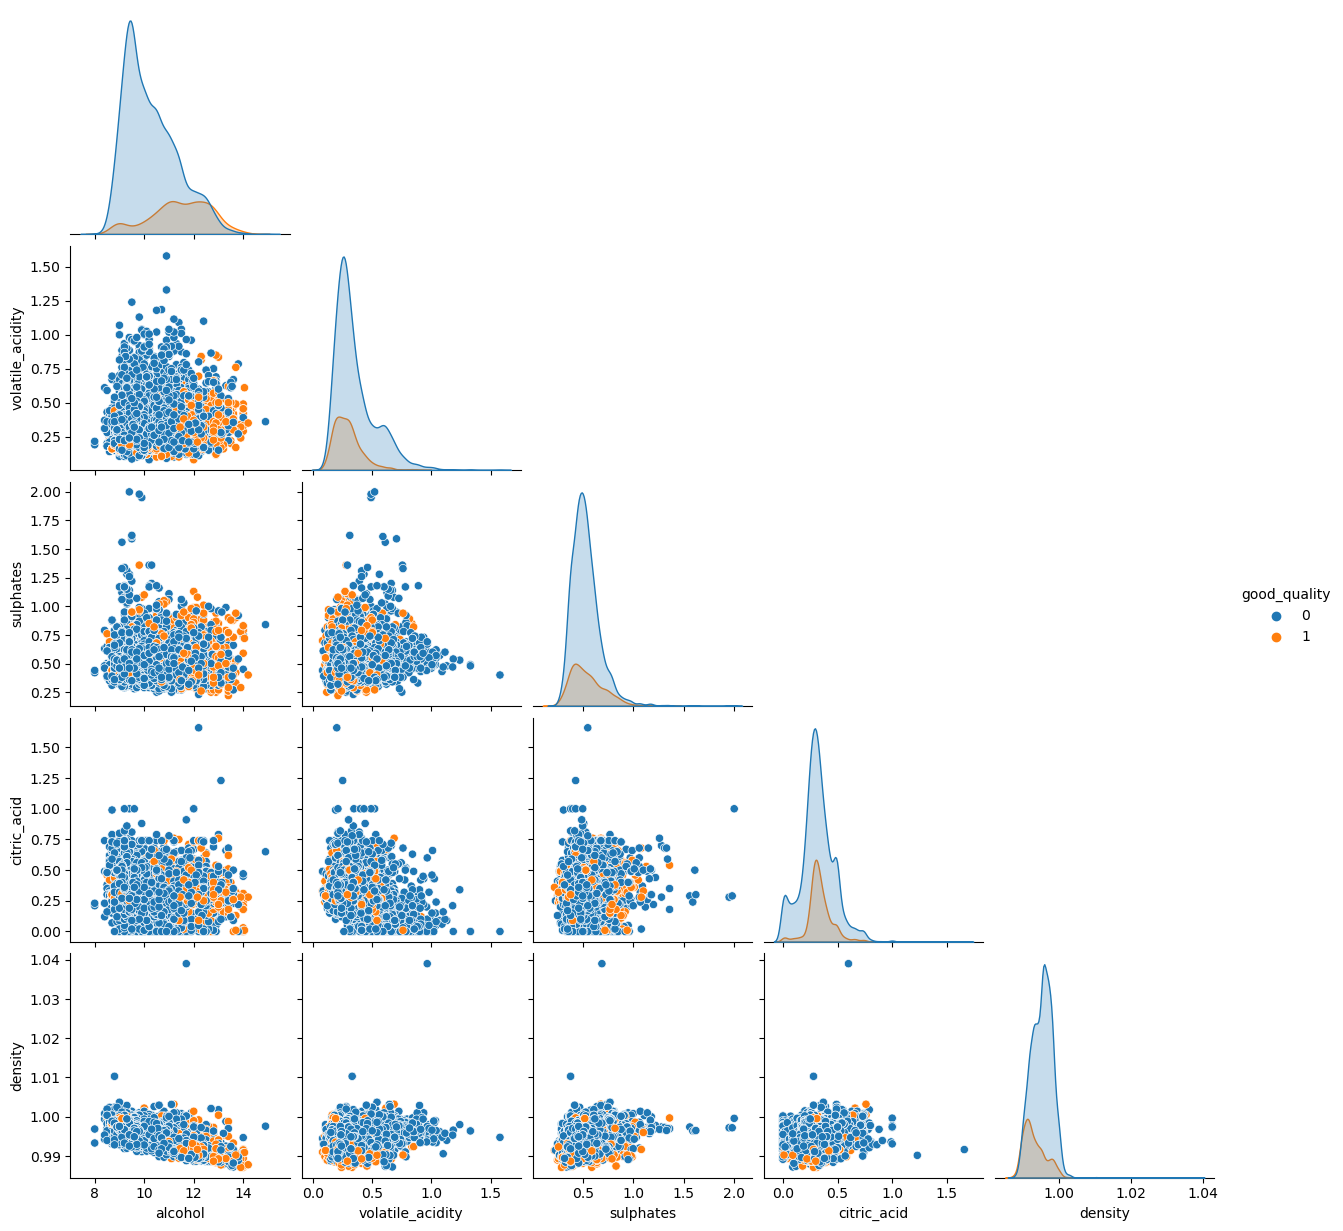

In [11]:
### 2.1.5. Performing numerical and visual analysis of plots and results

## 2.1.5.a. Numerical correlation analysis
correlation_matrix = wine_df.drop('quality', axis = 1).corr(numeric_only=True).round(2)
correlation_matrix['good_quality']

## 2.1.5.b. Visual correlation analysis (via Seaborn's Heatmap)
plt.figure(figsize=(20, 16))
sns.heatmap(data = correlation_matrix)
plt.show()

## 2.1.5.c. Visual correlation anylsis (via Seaborn's PairPlot)
pair_features = ['alcohol', 'volatile_acidity', 'sulphates', 'citric_acid', 'density', 'good_quality']
sns.pairplot(wine_df[pair_features], hue='good_quality', corner=True)
plt.show()

In [12]:
### 2.1.6. Identifying a few important attributes
correlation_matrix['good_quality']

features = ['alcohol', 'volatile_acidity', 'density', 'chlorides', 'citric_acid']
x = x_std[features]

### 2.2. Model Construction
Finally after pre-processing, we can proceed to the model construction of the Random Forest Classifier. In this model construction, we will be importing the [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) library from [Scikit-learn](https://scikit-learn.org/stable/), and using [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) for hyper-parameter tuning and cross-validation.

In [13]:
### 2.2.1. Splitting data into training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5, stratify=y)

In [30]:
### 2.2.2. Parameter Grid builder for parameter training (GridSearchCV)
rf = RandomForestClassifier(random_state=5)

params = { 'max_depth': [5, 7, 9],
           'n_estimators': [50, 100, 200],
           'max_features': ['sqrt', 'log2']
         }

gs_rf = GridSearchCV(rf, params, cv=10, scoring='accuracy', return_train_score=False)
gs_rf.fit(x_train, y_train)

gs_rf.best_params_

{'max_depth': 9, 'max_features': 'sqrt', 'n_estimators': 50}

In [31]:
## 2.2.2.a. find best model score
gs_rf.score(x_test, y_test)

0.8384615384615385

In [16]:
### 2.2.3. Hyper-parameter tuning results (log of every combination tested)
results_df = pd.DataFrame(gs_rf.cv_results_)
results_df = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results_df = results_df.sort_values('rank_test_score')
results_df

,params,mean_test_score,std_test_score,rank_test_score
15,"{'max_depth': 9, 'max_features': 'log2', 'n_es...",0.846064,0.005791,1
12,"{'max_depth': 9, 'max_features': 'sqrt', 'n_es...",0.846064,0.005791,1
13,"{'max_depth': 9, 'max_features': 'sqrt', 'n_es...",0.843948,0.007577,3
16,"{'max_depth': 9, 'max_features': 'log2', 'n_es...",0.843948,0.007577,3
17,"{'max_depth': 9, 'max_features': 'log2', 'n_es...",0.841446,0.007024,5
14,"{'max_depth': 9, 'max_features': 'sqrt', 'n_es...",0.841446,0.007024,5
7,"{'max_depth': 7, 'max_features': 'sqrt', 'n_es...",0.838559,0.007837,7
10,"{'max_depth': 7, 'max_features': 'log2', 'n_es...",0.838559,0.007837,7
6,"{'max_depth': 7, 'max_features': 'sqrt', 'n_es...",0.838367,0.004430,9
9,"{'max_depth': 7, 'max_features': 'log2', 'n_es...",0.838367,0.004430,9


### 2.3. Tree Visualization
After we have constructed the model, we can now move to visualizing one tree from the best Random Forest found by GridSearchCV using [graphviz](https://graphviz.readthedocs.io/en/stable/).

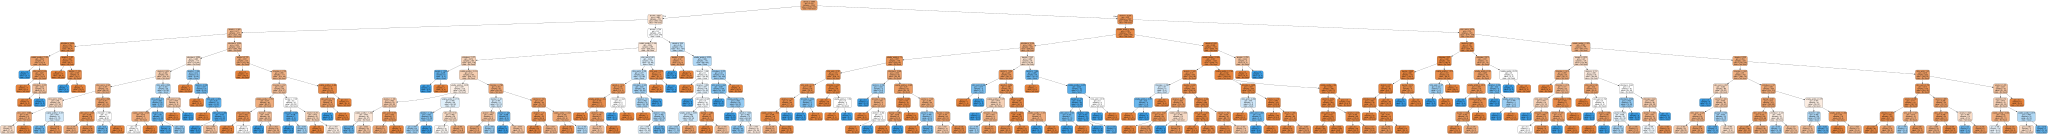

In [33]:
### 2.3.1. Visualizing one tree from the best Random Forest
best_rf = gs_rf.best_estimator_
one_tree = best_rf.estimators_[0]

dot_data = export_graphviz(
    one_tree,
    out_file = None,
    feature_names = features,
    class_names = ['Not Good', 'Good'],
    filled=True, rounded=True,
    special_characters=True,
)


## 2.3.1.a. Rendering with graphviz
graph = graphviz.Source(dot_data)
graph

### 2.4. Result Analysis
In this final step, we evaluate the best Random Forest on the untouched test set using the confusion matrix, precision, recall, F1-score, ROC curve, and Precision-Recall curve.

In [21]:
### 2.4.1. Predictions and Classifications Report
## 2.4.1.a. Predict the response for test dataset
predictions = gs_rf.predict(x_test)
predicted_probas = gs_rf.predict_proba(x_test)

# Predictions contain predicted values (derived from probability with 0.5. threshold)
print(classification_report(y_test, predictions))
print('Accuracy: ', accuracy_score(y_test, predictions))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      1044
           1       0.68      0.34      0.46       256

    accuracy                           0.84      1300
   macro avg       0.77      0.65      0.68      1300
weighted avg       0.82      0.84      0.82      1300

Accuracy:  0.8384615384615385


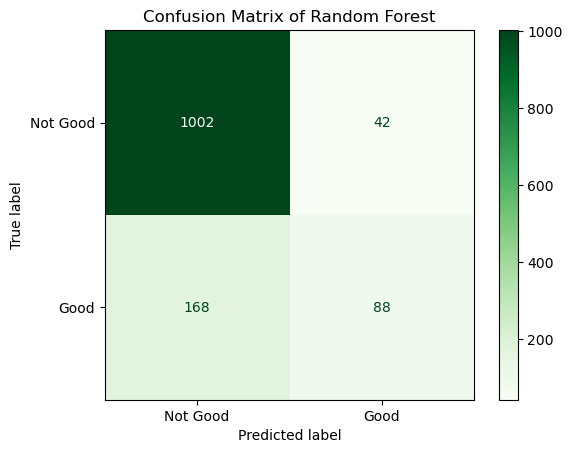

In [22]:
### 2.4.2. Confusion Matrix
ConfusionMatrix = confusion_matrix(y_test, predictions)
ConfusionMatrix

ConfusionMatrixDisplay(confusion_matrix = ConfusionMatrix, display_labels=['Not Good', 'Good']).plot(cmap='Greens')
plt.title('Confusion Matrix of Random Forest')
plt.show()

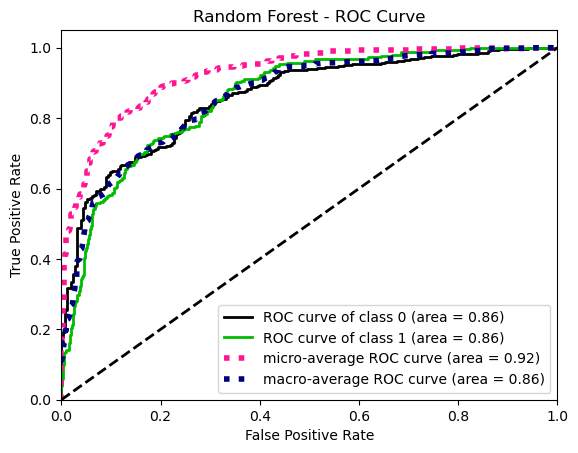

In [24]:
### 2.4.3. ROC Curve
skplt.metrics.plot_roc(y_test, predicted_probas, title = 'Random Forest - ROC Curve')
plt.show()

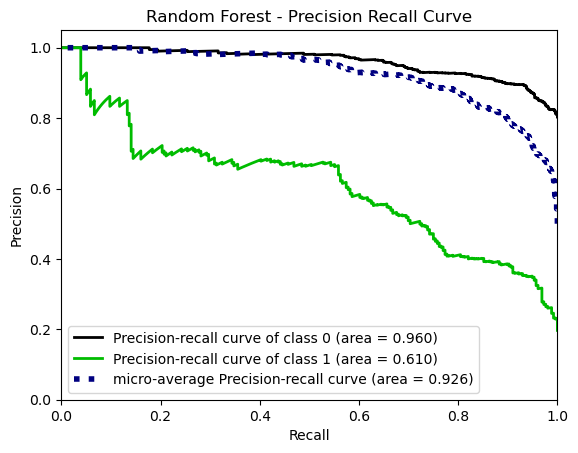

In [25]:
### 2.4.4. Precision-Recall Curve
skplt.metrics.plot_precision_recall(y_test, predicted_probas, title = 'Random Forest - Precision Recall Curve')
plt.show()

In [26]:
### 2.4.5. Freature Importances
pd.DataFrame([best_rf.feature_importances_], columns = features)

,alcohol,volatile_acidity,density,chlorides,citric_acid
0,0.318999,0.148714,0.238965,0.153183,0.140139
